# Trading Game #2:

## Beating Passive Strategies in the Bullish Commodity Markets


In this project, we study a pairs trading strategy applied to the palm oil sector.

The goal is to check if an active strategy of pairs trading can outperfom simple Buy & Hold strategies, especially in a bullish market. Pairs trading is based on the idea that some assets move together in the long run when they diverge, we can trade the spread and expect a return to equilibrium.

We used the Palazzi "Trading Games: Beating Passive Strategies in the Bullish
Crypto Market" to implement our strategy.

## 1.Data loading and train/ test split

In [1]:
# Trading Game #2

# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from google.colab import files
import io



#We load the dataset that we already cleaned and created to use it for the strategy of the game 2
print("Please upload palm_oil_dataset1.csv")
uploaded = files.upload()
# we convert date column to datetime and set it as index
palm_oil_data = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
palm_oil_data["Date"] = pd.to_datetime(palm_oil_data["Date"])
palm_oil_data = palm_oil_data.set_index("Date")


Please upload palm_oil_dataset1.csv


Saving palm_oil_dataset1.csv to palm_oil_dataset1.csv


Shape :   (1869, 15)   and columns of our dataset : 

 ['5JS.SI', 'AALI.JK', 'BWPT.JK', 'DBA', 'E5H.SI', 'EB5.SI', 'LSIP.JK', 'MOO', 'P8Z.SI', 'RJA', 'SIMP.JK', 'SMAR.JK', 'SSMS.JK', 'TBLA.JK', 'UNSP.JK']  

Train period : 2015-01-02 to 2020-06-30 
Number of observations : 1308

Test  period : 2020-07-01 to 2022-11-21  
Number of observations : 561  



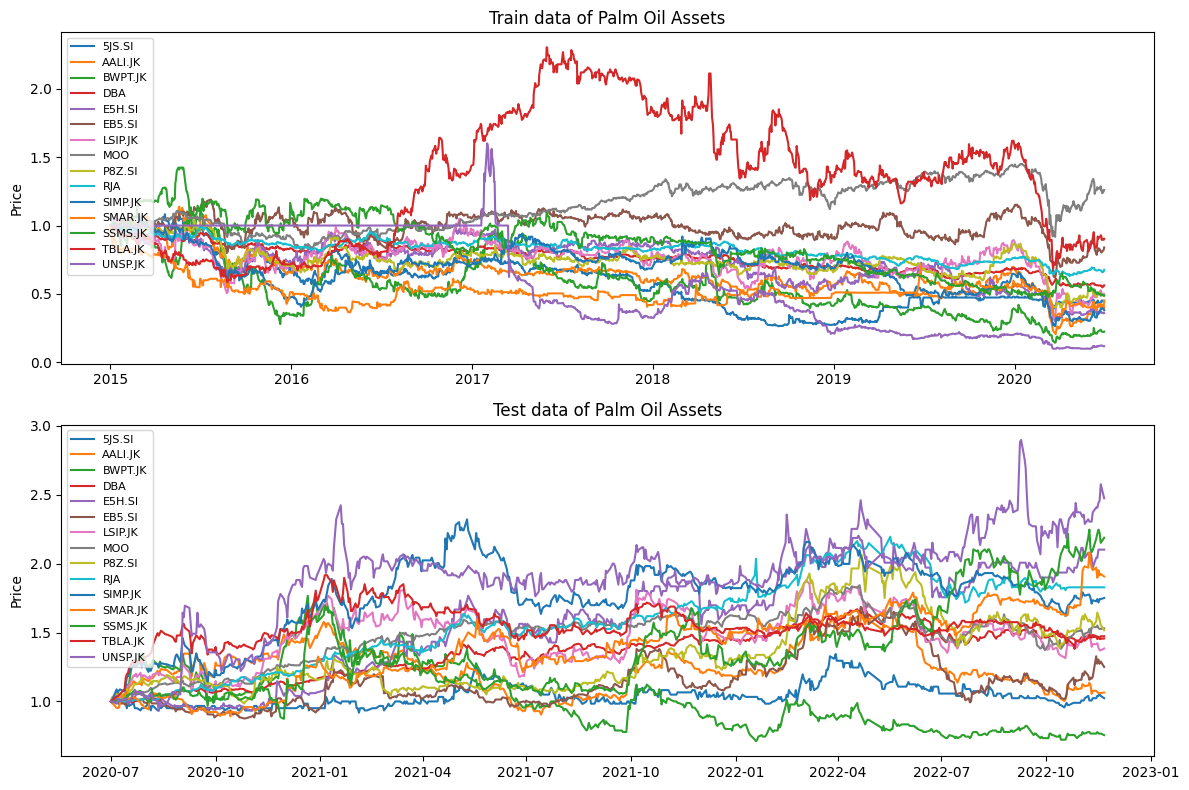

In [11]:

#we split the data into train and test
# we keep 70% for training and 30% for testing
split_ratio=  0.70

# we compute the index to find where to split the dataset in train/test
split_index= int(len(palm_oil_data) * split_ratio)
palm_oil_train =palm_oil_data.iloc[:split_index]
palm_oil_test = palm_oil_data.iloc[split_index:]

print(f"Shape :   {palm_oil_data.shape}   and columns of our dataset : \n\n {palm_oil_data.columns.tolist()}  " )
print(f"\nTrain period : {palm_oil_train.index[0].date()} to {palm_oil_train.index[-1].date()} ")
print(f"Number of observations : {len(palm_oil_train)}")
print(f"\nTest  period : {palm_oil_test.index[0].date()} to {palm_oil_test.index[-1].date()}  ")
print(f"Number of observations : {len(palm_oil_test)}  \n")

# we plot train and test prices
#we create two graphes
fig, (axe_train, axe_test) =plt.subplots(2 , 1, figsize=(12, 8), sharex=False)

# normalisation to compare all assets
train_norm = palm_oil_train / palm_oil_train.iloc[0]
test_norm = palm_oil_test / palm_oil_test.iloc[0]

#train data
axe_train.plot(train_norm)
axe_train.set_title("Train data of Palm Oil Assets")
axe_train.set_ylabel("Price")
axe_train.legend(palm_oil_train.columns, loc="upper left", fontsize=8)

#test data
axe_test.plot(test_norm)
axe_test.set_title("Test data of Palm Oil Assets")
axe_test.set_ylabel("Price")
axe_test.legend(palm_oil_test.columns, loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()



In the training period :2015–2020, most assets lose value over time. The market is mostly going down or staying flat for palm oil stocks. In the test period (2020 to 2022), we can see a strong increase for most assets. This is a rising market, helped by the recovery after covid and the increase in commodity prices in 2022.

And this is important to understand because pairs trading works better in stable markets where prices go up and down around a normal level. When prices go strongly in one direction, it is harder to make profit from price differences.

## 2. Pair Selection with cointegration and Sharpe ranking

We choose DBA as our anchor for this project and we are going to test wich other asset has the strongest long run relationship with DBA.

Following Pallazi, we didn't pick just the lowest p value, we pick the one that gives the best sharpe ratio in sample.  

In [12]:
# we define the anchor asset
anchor_palm_oil = "DBA"
# we store results of cointegration tests
results = []

# we test cointegration between anchor and all other assets
for asset in palm_oil_train.columns:
    if asset != anchor_palm_oil:
        score, pvalue, _ = coint(palm_oil_train[anchor_palm_oil], palm_oil_train[asset])
        results.append((asset, pvalue))

# we create a dataframe with p-values
coint_palm_oil_data = pd.DataFrame(results, columns=["Asset", "pvalue"])
# we sort by p-value (lowest = strongest relationship)
coint_palm_oil_data = coint_palm_oil_data.sort_values("pvalue").reset_index(drop=True)

# instead of selecting only by p-value
# we select the best pair based on performance with the sharpe ratio
pair_results = []
for asset in palm_oil_train.columns:
    if asset != anchor_palm_oil:

# cointegration test
        score, pvalue, _ = coint(palm_oil_train[anchor_palm_oil], palm_oil_train[asset])
 # we keep only cointegrated pairs
        if pvalue < 0.05:
# we compute log prices
            y= np.log(palm_oil_train[anchor_palm_oil])
            x=np.log(palm_oil_train[asset])
# we estimate hedge ratio using OLS regression
            X=sm.add_constant(x)
            model= sm.OLS(y, X).fit()
            hedge_ratio =model.params.iloc[1]
# we compute spread
            spread=y -hedge_ratio* x
# we compute spread returns
            spread_ret = spread.diff()
# we compute z-score (mean reversion signal)
            z = (spread - spread.mean()) / spread.std()
# we generate trading signals
#1 = long, -1 = short, 0 = no position
            signal = np.where(z > 0.7, -1, np.where(z < -0.7, 1, 0))
            signal = pd.Series(signal, index=spread.index)
# we compute strategy returns
            strat_ret = signal.shift(1) * spread_ret
# we compute Sharpe ratio
            sharpe = np.sqrt(252) * strat_ret.mean() / strat_ret.std() if strat_ret.std() != 0 else np.nan
# we store results
            pair_results.append((asset, pvalue, sharpe))

# we create dataframe with results
pair_df = pd.DataFrame(pair_results, columns=["Asset", "pvalue", "Sharpe"])
# we sort by Sharpe ratio (best performance first)
pair_df = pair_df.sort_values("Sharpe", ascending=False)
# we select the best pair
pair_asset = pair_df.iloc[0]["Asset"]

print("\nCointegration p-values (train data):\n")
print(coint_palm_oil_data.to_string())
print("\nPair ranking based on Sharpe ratio:\n")
print(pair_df.head())
print(f"\nFinal selected pair: {anchor_palm_oil} and {pair_asset}")


Cointegration p-values (train data):

      Asset    pvalue
0   SSMS.JK  0.000218
1   AALI.JK  0.023107
2   UNSP.JK  0.031309
3       RJA  0.059039
4    E5H.SI  0.112304
5       MOO  0.116595
6    P8Z.SI  0.144091
7   BWPT.JK  0.167906
8    EB5.SI  0.198534
9   LSIP.JK  0.207208
10  SIMP.JK  0.564880
11   5JS.SI  0.686048
12  TBLA.JK  0.828036
13  SMAR.JK  0.848628

Pair ranking based on Sharpe ratio:

     Asset    pvalue    Sharpe
1  SSMS.JK  0.000218  1.681538
2  UNSP.JK  0.031309  1.392994
0  AALI.JK  0.023107  1.355842

Final selected pair: DBA and SSMS.JK


SSMS.JK has the lowest p-value = 0.0002. This means it has the strongest statistical link with DBA during the training period.
This p value is below 0.05 so it means we are confident that the two assets are cointegrated, so their prices move together in the long term.

Next, we rank all the cointegrated pairs using the Sharpe ratio from the training period. SSMS.JK also has the best Sharpe ratio with 1.68 . This shows it is the best pair to trade with DBA.

So the final pair selected is: DBA and SSMS.JK

## 3. Hedge Ratio and Spread

We estimate the hedge ratio using OLS regression, only on train data and keeping this fixed for testing the data after. It will tell us how much of SMS.JK we need to hedge one unit of DBA.


Hedge ratio estimated on training data: 0.4421  

 


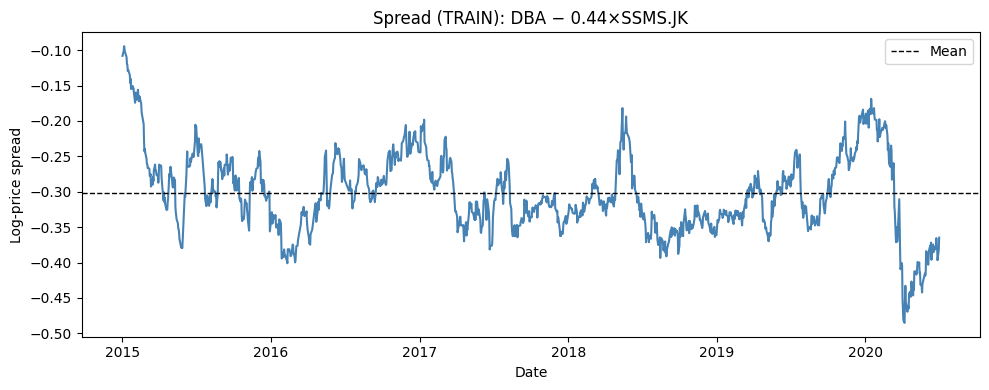

In [13]:
#we estimate the hedge ratioo on train data
log_train=np.log(palm_oil_train)

#variables definition
y= log_train[anchor_palm_oil]
x=log_train[pair_asset]

#regression with hedge ratio frozen for test set
X_train= sm.add_constant(x)
model= sm.OLS(y, X_train).fit()
hedge_ratio =model.params.iloc[1]
print(f"\nHedge ratio estimated on training data: {hedge_ratio:.4f}  \n\n ")

#we compute spread and plot it
spread_train= y-hedge_ratio*x
plt.figure(figsize=(10, 4))
plt.plot(spread_train, color="steelblue")
plt.axhline(spread_train.mean(), color="black", linestyle="--", linewidth=1, label="Mean")
plt.title(f"Spread (TRAIN): {anchor_palm_oil} − {hedge_ratio:.2f}×{pair_asset}")
plt.xlabel("Date")
plt.ylabel("Log-price spread")
plt.legend()
plt.tight_layout()
plt.show()

The hedge ratio is 0.44. This means that for 1 unit of DBA, we use 0.44 units of SSMS.JK to hedge. And we can see from the spread graph that the spread moves around a stable average. It goes up and down, but it always returns to this average
This is called mean reversion, and it is very important for pairs trading
because this behavior during the training period is a good sign. It shows that DBA and SSMS.JK move together in the long term, and that the spread is stable.

##4. Dynamic Lookback Optimization

Following the Pallazi game, we test all loockback windows from 5 to 355 days and keep the one that gives the best sharpe ratio on the training data


In [14]:
#we calibrate volatility filter only on train data
vol_lookback=30  #we take 30 days to compute rolling volatility
vol_threshold =1.5 #we stop trading if volatility > 1.5 times the average

# we compuute spread strategy_returnurns and rolling volatility to have the avergae of volatility
spread_strategy_returns =spread_train.diff()
spread_volatility= spread_strategy_returns.rolling(vol_lookback).std()
average_volatility=spread_volatility.mean()
print("Average spread volatility :", average_volatility)

# lookback optimisation to find the best lookback window
lookback_range=range(5, 360, 5)
best_sharpe= -np.inf  # we initializ_scoree with very low value
best_lookback = None

for lookback in lookback_range:
#we compute rolling mean and std of spread and the z score
    mean= spread_train.rolling(lookback).mean()
    std= spread_train.rolling(lookback).std()
    z_score=(spread_train - mean)/std

#we create trading signalnals (1 to buy, -1 to sell, and 0 : no positionition)
    signal = pd.Series(0, index=palm_oil_train.index)
    signal[z_score > 0.7] =-1
    signal[z_score < -0.7]=1

# we had to applu volatility filter to not trade if volatility is too high
    filter_volatility= spread_volatility<=vol_threshold *average_volatility
    signal[~filter_volatility] =0

# compute strategy return and sharpe ratio
    strategy_return= signal.shift(1) * spread_strategy_returns
    sharpe = np.sqrt(252) * strategy_return.mean() /strategy_return.std() if strategy_return.std() != 0 else np.nan
    #we update best result if current one is better
    if not np.isnan(sharpe) and sharpe> best_sharpe:
        best_sharpe= sharpe
        best_lookback =lookback

print(f"\nOptimal lookback : {best_lookback} days")
print(f"Sharpe on train data: {best_sharpe:.3f}")


Average spread volatility : 0.01138052734241066

Optimal lookback : 340 days
Sharpe on train data: 0.985


The average spread volatility is 0.0114. We use this as a reference. If the current volatility is more than 1.5 times this value, we do not open new trades because the market is too unstable.We can also see that the best lookback is 340 days. This means using a long period gives better signals for this pair. This makes sense because the spread between DBA and SSMS.JK moves slowly so a short period would create too much noise.

The best Sharpe ratio in the training period is 0.985, which is a good result. But this number may be too optimistic because it was calculated using the same data we used to choose the lookback. So we need to check the result on the test period

## 5. Signal Function with the volatility filter and adaptive stop-loss

This fonction builds the full trading signal with 3 rules to stay safe and not trade if the conditions are not reunited.

First, we have a volatility filter to not trade when the market is too volatile by looking at the spread volatility over the last 30 days and we not trade if it's 1,5 times the average level. Then we have the minimum holding period to keep positions at least 5 days to avoid over trading and finally we have the adaptative trailing stop loss to exit if the spread moves in the wrong direction.

In [15]:
# we define the fonction to build trading signal

def build_signal(spread, return_strategy, lookback,average_vol, vol_threshold, vol_lookback, entry_z_score=0.7, stop_mult=2.0, min_holding=5):
#computing the z scrore
    rolling_mean= spread.rolling(lookback).mean().shift(1)
    rolling_std=spread.rolling(lookback).std().shift(1)
    zscore= (spread - rolling_mean) / rolling_std

#wee need the average std to use for the stop loss
    avg_rolling_std = rolling_std.mean()
#we compute volatility of spread returns and then then filter to not trade if volatility is too high
    spread_vol= return_strategy.rolling(vol_lookback).std()
    vol_filter =spread_vol <= vol_threshold * average_vol

#creation of the trading signal (1 to  buy, -1 to sell, and 0: no positionition)
    signal= np.where(zscore > entry_z_score, -1,  np.where(zscore < -entry_z_score,  1, 0))
    signal=pd.Series(signal, index=spread.index)
    # if volatility is to high, we remove trades
    signal[~vol_filter]= 0

#apply minimum holding period
    sig_filtered =signal.copy()
    current_position=0
    hold_days= 0
    for i in range(len(sig_filtered)):
        position = signal.iloc[i]
        if current_position != 0:
            hold_days += 1
            if hold_days < min_holding:
                sig_filtered.iloc[i] = current_position   # keep current positioni
            else:
                if position != current_position:
                    current_position= position
                    hold_days = 0
                sig_filtered.iloc[i] = current_position
        else:
            current_position= position
            sig_filtered.iloc[i] =current_position
            hold_days= 0
    signal= sig_filtered

# we apply adaptative trailing stop loss
    signal_stop=signal.copy()
    entry_zscore= None
    entry_std_v= None
    entry_position=0

    for i in range(len(signal_stop)):
        p = signal_stop.iloc[i]

#open new position
        if p != 0 and entry_position ==0:
            entry_zscore= zscore.iloc[i]
            entry_std_v= rolling_std.iloc[i] if not np.isnan(rolling_std.iloc[i]) else 1.0
            entry_position= p
# position closed by raw signal
        elif p == 0:
            entry_zscore= None
            entry_std_v= None
            entry_position= 0
#check stop condition
        elif entry_zscore is not None:
            cur_z = zscore.iloc[i]

#we adjust stop with volatility
            current_vol = rolling_std.iloc[i]
            if np.isnan(current_vol) or avg_rolling_std == 0:
                lambda_t = stop_mult
            else:
                lambda_t = stop_mult *max(current_vol / avg_rolling_std, 1.0)
            stop_dist = lambda_t*entry_std_v
# we exit if move is too large
            hit = (entry_position==  1 and cur_z < entry_zscore - stop_dist) or \
             (entry_position==-1 and cur_z> entry_zscore+ stop_dist)

            if hit:
                signal_stop.iloc[i]= 0
                entry_zscore= None
                entry_std_v= None
                entry_position= 0

    return signal_stop, zscore

## 6. Apply strategy on train and test sets and ADF test

In [16]:
# apply strategy on train data
spread_ret_train = spread_train.diff()
avg_vol_train = average_volatility
# build signal using train data
signal_train, zscore_train = build_signal(spread=spread_train,return_strategy=spread_ret_train,lookback=best_lookback,average_vol=average_volatility,vol_threshold=vol_threshold,vol_lookback=vol_lookback)
# compute strategy returns and cumulative performance
strat_ret_train=signal_train.shift(1) * spread_ret_train
strat_curve_train=(1 + strat_ret_train).cumprod()

#apply it on the test set
# we avoid look ahead bias by keeping the same parameters as in training to not reoptimize them on test data
log_test= np.log(palm_oil_test)
Y1_test=log_test[anchor_palm_oil]
Y2_test= log_test[pair_asset]
spread_test =Y1_test - hedge_ratio *Y2_test
spread_ret_test= spread_test.diff()

signal_test, zscore_test= build_signal(spread = spread_test, return_strategy= spread_ret_test,lookback = best_lookback, average_vol = avg_vol_train, vol_threshold= vol_threshold,vol_lookback= vol_lookback)
from statsmodels.tsa.stattools import adfuller
adf = adfuller(spread_test.dropna())
print(f"ADF p value sur spread test : {adf[1]:.4f}")

strat_ret_test= signal_test.shift(1) * spread_ret_test
strat_curve_test= (1 + strat_ret_test).cumprod()

ADF p value sur spread test : 0.4278


The ADF p-value is 0.4278, which is much higher than 0.05. This means the spread is not stable anymore in the test period. So DBA and SSMS.JK don't move together anymore. The relationship we saw before is now broken ans we can think that its due to the test period with changes causing by covid 19 and the war in Ukraine that pushed prices much higher than usual.

Because of these big events, the link between the two assets changed and it's not optimal in pairs traiding.

## 7. Z-Score plots

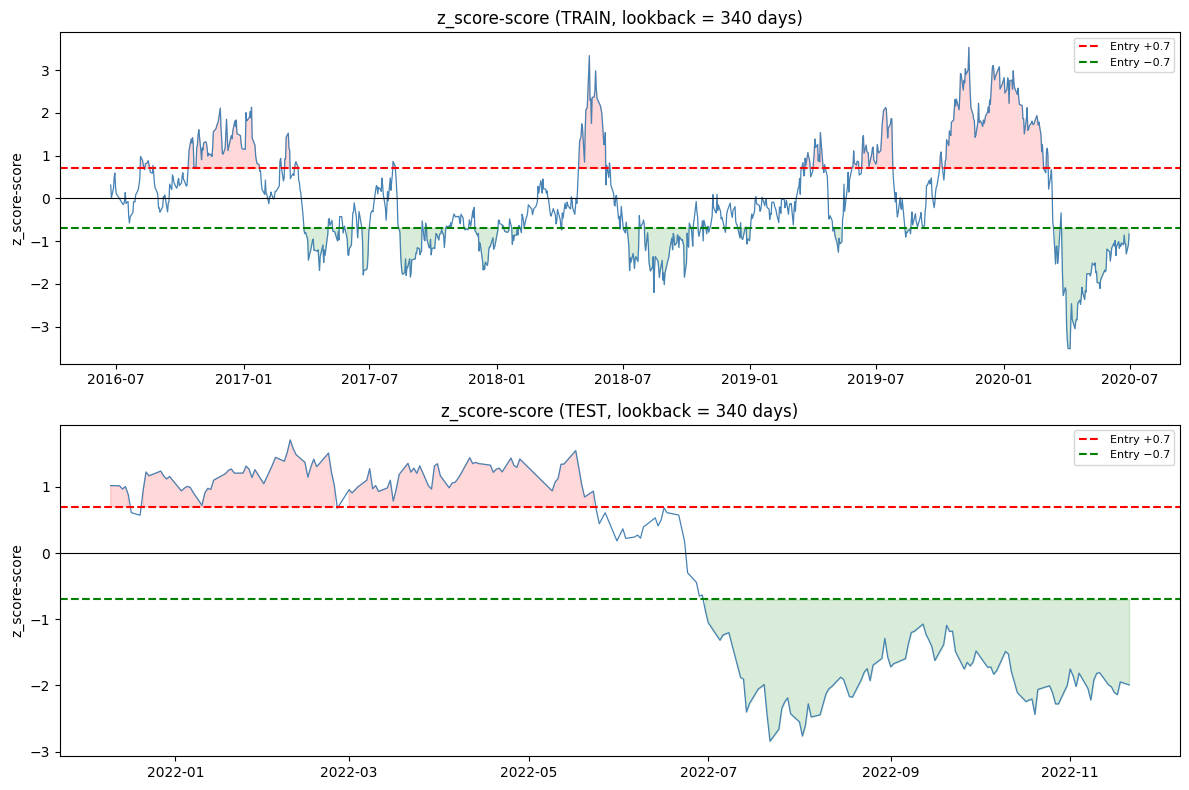

In [17]:
#plot z score for train and test periods with entry thresholds
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
for ax, z_scores, label in [(ax1, zscore_train, "TRAIN"), (ax2, zscore_test, "TEST")]:
    ax.plot(z_scores, color="steelblue", linewidth=0.9)
# entry thresholds with +0,7 for short signals and and -0,7 for long signal
    ax.axhline( 0.7, color="red",   linestyle="--", label="Entry +0.7")
    ax.axhline(-0.7, color="green", linestyle="--", label="Entry −0.7")
    ax.axhline( 0,   color="black", linewidth=0.8)
#setting some colours where z score is under or above the two threshold zones
    ax.fill_between(z_scores.index,  0.7, z_scores.where(z_scores >  0.7), color="red",   alpha=0.15)
    ax.fill_between(z_scores.index, -0.7, z_scores.where(z_scores < -0.7), color="green", alpha=0.15)
    ax.set_title(f"z_score-score ({label}, lookback = {best_lookback} days)")
    ax.set_ylabel("z_score-score")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

On the training period in the first chart, the z-score moves around zero and often crosses +0.7 and -0.7. This is good for pairs trading. The spread goes away from its average and then comes back. When it crosses a threshold, we open a trade and we close it when it goes back near zero

On the test period in the second chart, the z-score is very different. At the start, it stays above +0.7 and then drops and stays below -0.7. It just goes in one direction and is not coming back to its average anymore. So strategy still opens trades, but the spread does not come back. So trades stay open too long or end with losses. This is why results are bad in the test period.

## 8. Cumulative performance plots

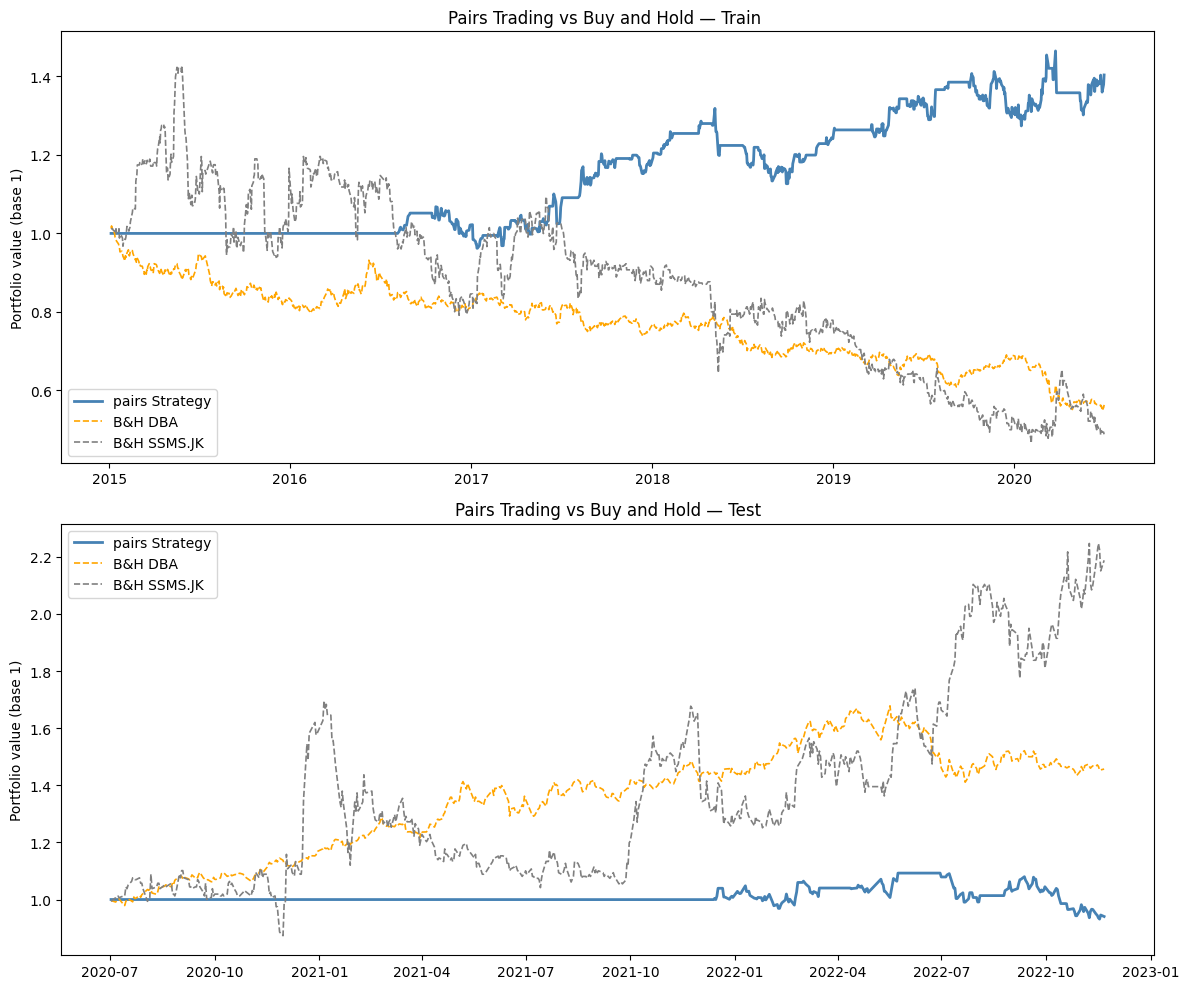

In [18]:
#we compute buy and hold returns to see the comparison
#daily returns for anchor and SSMS.JK on train set
anchor_palm_oil_strategy_return_train =palm_oil_train[anchor_palm_oil].pct_change()
equity_strategy_return_train= palm_oil_train[pair_asset].pct_change()
#cumulative performance starting at 1
bh_anchor_palm_oil_train = (1 + anchor_palm_oil_strategy_return_train).cumprod()
bh_equity_train=(1 + equity_strategy_return_train).cumprod()
# same for test set
anchor_palm_oil_strategy_return_test=palm_oil_test[anchor_palm_oil].pct_change()
equity_strategy_return_test= palm_oil_test[pair_asset].pct_change()
bh_anchor_palm_oil_test= (1 + anchor_palm_oil_strategy_return_test).cumprod()
bh_equity_test =(1 + equity_strategy_return_test).cumprod()

#plot pairs strategy vs buy and hold for train and test
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
for ax, sc, bha, bhe, lbl in [(ax1, strat_curve_train, bh_anchor_palm_oil_train, bh_equity_train, "Train "),(ax2, strat_curve_test,  bh_anchor_palm_oil_test,  bh_equity_test,  "Test")]:
    ax.plot(sc,  label="pairs Strategy", linewidth=2, color="steelblue")
    ax.plot(bha, label=f"B&H {anchor_palm_oil}",  linestyle="--", color="orange",  linewidth=1.2)
    ax.plot(bhe, label=f"B&H {pair_asset}", linestyle="--", color="gray", linewidth=1.2)
    ax.set_title(f"Pairs Trading vs Buy and Hold — {lbl}")
    ax.set_ylabel("Portfolio value (base 1)")
    ax.legend()

plt.tight_layout()
plt.show()

On the training period on the first chart, the pairs trading strategy does better than Buy & Hold. We have :

DBA loses about 40% and SSMS.JK loses about 45%
Our strategy gains about 40%

This shows the strategy works well when the market is stable.
The performance grows step by step, because it makes small profits each time the spread comes back.

But on the test period on the second chart, it's the opposite

DBA gains about +45% and SSMS.JK gains about +120%
And our strategy stays almost flat and ends slightly negative

This happens because the spread does not come back to normal. So the strategy cannot make many profits. The market is going up strongly, so Buy & Hold works better than this strategy.

## 9.Performance metrics : sharpe, max drawdown and calmar

In [19]:
#performance metrics functions

#the return divided by risk annualized for sharpe ratio
def sharpe_ratio(r):
    std = r.std()
    return np.sqrt(252) * r.mean() / std if std != 0 else np.nan

#the worst loss from the highest pic on the curve
def max_drawdown(curve):
    roll_max = curve.cummax()
    return (curve / roll_max - 1).min()

#annual return divided by absolute max drawdown
def calmar_ratio(annual_return, mdd):
    return annual_return / abs(mdd) if mdd != 0 else np.nan
#we build one row of the performance table for both strategies
def performance_row(label, return_series, curve):
    ann = return_series.mean() * 252
    sharpe = sharpe_ratio(return_series)
    mdd = max_drawdown(curve)
    calmar = calmar_ratio(ann, mdd)
    return {"Strategy": label,"Annual Return": ann, "Sharpe Ratio": sharpe,"Max Drawdown": mdd, "Calmar Ratio": calmar}




# print performance tables
for label, (sr, sc, ar, ac, er, ec) in {
    "train data ": (strat_ret_train,  strat_curve_train,anchor_palm_oil_strategy_return_train, bh_anchor_palm_oil_train,equity_strategy_return_train, bh_equity_train),
   "test data ": (strat_ret_test,  strat_curve_test,anchor_palm_oil_strategy_return_test, bh_anchor_palm_oil_test,equity_strategy_return_test, bh_equity_test)
   }.items():
    rows = [performance_row("Pairs Trading", sr, sc), performance_row(f"Buy & Hold {anchor_palm_oil}", ar, ac),performance_row(f"Buy & Hold {pair_asset}", er, ec)]
    tbl = pd.DataFrame(rows)
    print(f"  \n Performance summary : {label}\n")
    print(tbl.round(3).to_string(index=False))


  
 Performance summary : train data 

          Strategy  Annual Return  Sharpe Ratio  Max Drawdown  Calmar Ratio
     Pairs Trading          0.072         0.627        -0.146         0.495
    Buy & Hold DBA         -0.103        -0.843        -0.462        -0.224
Buy & Hold SSMS.JK         -0.084        -0.254        -0.673        -0.125
  
 Performance summary : test data 

          Strategy  Annual Return  Sharpe Ratio  Max Drawdown  Calmar Ratio
     Pairs Trading         -0.020        -0.161        -0.148        -0.135
    Buy & Hold DBA          0.181         1.172        -0.159         1.138
Buy & Hold SSMS.JK          0.458         0.986        -0.386         1.187


For the Training period, we can see that pairs strategy works very well.
It makes money with +7% per year, while both DBA and SSMS.JK lose money. It also has lower risk, with much smaller losses than Buy & Hold. This shows the strategy is good in a stable or falling market, where prices move around a normal level.

For the test period, the strategy does not work well by losing money (-2%), while DBA and SSMS.JK go up a lot. The risk is still controlled with losses that are not very big, but the strategy does not make profit.

We think that it fails because DBA and SSMS.JK stop moving together in this period.The spread does not come back to normal, so the strategy cannot win.

This happens because of big events that increased a lot prices. So the strategy stays mostly inactive and misses the strong upward trend.

## Final Conclusion

The strategy found that DBA and SSMS.JK move together in the training period
All tools were used: lookback (340 days), volatility filter, and stop-loss
Results are good in training: positive return and low risk, the strategy does better than Buy & Hold from 2015 to 2020

But,the test period (2020–2022) was very unusual with big events like covid and the war in Ukraine changed the market so DBA and SSMS.JK stop moving together. The strategy cannot work because the spread does not come back
Buy & Hold works better because the market goes up strongly

Pairs trading does not try to follow the market trend. It only works when prices move around a normal level.
When this link breaks because of big events, the strategy stops working. This is normal for this type of strategy.And the good point is that the risk tools helped limit losses in the test period.